In [1]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import shap

In [2]:
X = pd.read_pickle('../../data/shap/fuzzy_x_20240106_values.pkl')
shap_values = np.load('../../data/shap/fuzzy_cat_20240106_shap_values.npy')
shap_interaction_values = np.load('../../data/shap/fuzzy_cat_20240106_shap_interaction_values.npy')

In [3]:
X = X.round(4)
shap_values = np.round(shap_values, 4)
shap_interaction_values = np.round(shap_interaction_values, 4)

In [4]:
variable_A_name = "Sh_4(mu)"
variable_A_index = X.columns.get_loc(variable_A_name)
variable_B_name = "Tipo P"
variable_B_index = X.columns.get_loc(variable_B_name)

In [5]:
from cgt_perezsechi.exploration.sampling import sample_size_kruskal_wallis

sample_size = sample_size_kruskal_wallis(X, shap_values, variable_A_name, acceleration=1)
if sample_size < len(X) / 10:
    sample_size = len(X) // 10

In [6]:
from cgt_perezsechi.manipulation.coding import code_interval

X_coded = code_interval(X, variable_A_name, sample_size)
df_A = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    'shap': shap_values[:, X.columns.get_loc(variable_A_name)]
})

In [7]:
df_B = pd.DataFrame({
    variable_B_name: X[variable_B_name],
    'shap': shap_values[:, X.columns.get_loc(variable_B_name)]
})

## Construcción de matrices de adyacencia

In [8]:
shap_interaction_values_A_B = shap_interaction_values[:, variable_A_index, variable_B_index]
df_interaction = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    variable_B_name: X_coded[variable_B_name],
    'shap_interaction': shap_interaction_values_A_B
})
df_interaction_grouped = df_interaction.groupby([variable_A_name, variable_B_name]).agg(["mean"]).reset_index()
df_interaction_grouped.columns = [variable_A_name, variable_B_name, 'shap_interaction']
df_interaction_grouped

,Sh_4(mu),Tipo P,shap_interaction
0,"[0.0,0.1067]",0,-5287.944229
1,"[0.0,0.1067]",1,9151.426462
2,"[0.108,0.1724]",0,-3825.232856
3,"[0.108,0.1724]",1,5744.472480
4,"[0.1726,0.2122]",0,-2009.165769
5,"[0.1726,0.2122]",1,3228.140933
6,"[0.2123,0.2484]",0,72.906460
7,"[0.2123,0.2484]",1,-9.924011
8,"[0.2487,0.2875]",0,1149.067871
9,"[0.2487,0.2875]",1,-1764.916667


In [9]:
unique_A_values = df_interaction_grouped[variable_A_name].unique()
unique_B_values = df_interaction_grouped[variable_B_name].unique()
variable_A_column_names = [f"{variable_A_name}_{value}" for value in unique_A_values]
variable_B_column_names = [f"{variable_B_name}_{value}" for value in unique_B_values]
column_names = variable_A_column_names + variable_B_column_names
r = pd.DataFrame(
    columns=column_names,
)

for A_value in unique_A_values:
    for B_value in unique_B_values:
        index_A = f"{variable_A_name}_{A_value}" 
        index_B = f"{variable_B_name}_{B_value}" 
        shap_interaction = df_interaction_grouped[
            (df_interaction_grouped[variable_A_name] == A_value) &
            (df_interaction_grouped[variable_B_name] == B_value)
        ]['shap_interaction'].values[0]
        r.loc[index_A, index_B] = shap_interaction
        r.loc[index_B, index_A] = shap_interaction

r.replace(np.nan, 0, inplace=True)
r_1 = r

/tmp/ipykernel_25928/2317974099.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r.replace(np.nan, 0, inplace=True)


In [10]:
r_1

,"Sh_4(mu)_[0.0,0.1067]","Sh_4(mu)_[0.108,0.1724]","Sh_4(mu)_[0.1726,0.2122]","Sh_4(mu)_[0.2123,0.2484]","Sh_4(mu)_[0.2487,0.2875]","Sh_4(mu)_[0.2875,0.3465]","Sh_4(mu)_[0.3467,0.7839]",Tipo P_0,Tipo P_1
"Sh_4(mu)_[0.0,0.1067]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5287.944229,9151.426462
Tipo P_0,-5287.944229,-3825.232856,-2009.165769,72.906460,1149.067871,3719.287513,7007.645464,0.000000,0.000000
Tipo P_1,9151.426462,5744.472480,3228.140933,-9.924011,-1764.916667,-6239.757693,-11003.376249,0.000000,0.000000
"Sh_4(mu)_[0.108,0.1724]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3825.232856,5744.472480
"Sh_4(mu)_[0.1726,0.2122]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2009.165769,3228.140933
"Sh_4(mu)_[0.2123,0.2484]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.906460,-9.924011
"Sh_4(mu)_[0.2487,0.2875]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1149.067871,-1764.916667
"Sh_4(mu)_[0.2875,0.3465]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3719.287513,-6239.757693
"Sh_4(mu)_[0.3467,0.7839]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7007.645464,-11003.376249


## Representación en grafo de la interacción entre valores de las variables "age" y "sex_isFemale"

In [11]:
df_A_stats = df_A.groupby(variable_A_name).agg(['mean']).reset_index()
df_A_stats.columns = [variable_A_name, 'shap']
df_B_stats = df_B.groupby(variable_B_name).agg(['mean']).reset_index()
df_B_stats.columns = [variable_B_name, 'shap']

In [12]:
df_A_stats

,Sh_4(mu),shap
0,"[0.0,0.1067]",70519.357614
1,"[0.108,0.1724]",33294.556528
2,"[0.1726,0.2122]",16699.755492
3,"[0.2123,0.2484]",-2830.184283
4,"[0.2487,0.2875]",-11665.079506
5,"[0.2875,0.3465]",-31219.640230
6,"[0.3467,0.7839]",-82434.308081


In [13]:
psi_1 = pd.DataFrame(
    columns=['value'],
)

for index, row in df_A_stats.iterrows():
    psi_1.loc[f'{variable_A_name}_{row[variable_A_name]}', 'value'] = row['shap']
for index, row in df_B_stats.iterrows():
    psi_1.loc[f'{variable_B_name}_{row[variable_B_name]:.0f}', 'value'] = row['shap']

psi_1.index.name = None
psi_1

,value
"Sh_4(mu)_[0.0,0.1067]",70519.357614
"Sh_4(mu)_[0.108,0.1724]",33294.556528
"Sh_4(mu)_[0.1726,0.2122]",16699.755492
"Sh_4(mu)_[0.2123,0.2484]",-2830.184283
"Sh_4(mu)_[0.2487,0.2875]",-11665.079506
"Sh_4(mu)_[0.2875,0.3465]",-31219.64023
"Sh_4(mu)_[0.3467,0.7839]",-82434.308081
Tipo P_0,-12265.838634
Tipo P_1,20139.475231


In [14]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1)

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


In [15]:
r_2

,"Sh_4(mu)_[0.0,0.1067]","Sh_4(mu)_[0.108,0.1724]","Sh_4(mu)_[0.1726,0.2122]","Sh_4(mu)_[0.2123,0.2484]","Sh_4(mu)_[0.2487,0.2875]","Sh_4(mu)_[0.2875,0.3465]","Sh_4(mu)_[0.3467,0.7839]",Tipo P_0,Tipo P_1
"Sh_4(mu)_[0.0,0.1067]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.480575,0.831693
Tipo P_0,-0.480575,-0.347642,-0.182595,0.006626,0.104429,0.338013,0.636863,0.000000,0.000000
Tipo P_1,0.831693,0.522065,0.293377,-0.000902,-0.160398,-0.567077,-1.000000,0.000000,0.000000
"Sh_4(mu)_[0.108,0.1724]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.347642,0.522065
"Sh_4(mu)_[0.1726,0.2122]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.182595,0.293377
"Sh_4(mu)_[0.2123,0.2484]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006626,-0.000902
"Sh_4(mu)_[0.2487,0.2875]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.104429,-0.160398
"Sh_4(mu)_[0.2875,0.3465]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.338013,-0.567077
"Sh_4(mu)_[0.3467,0.7839]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636863,-1.000000


In [16]:
import regex as re
# Create new column names with TeX expressions
r_2_cols = r_2.columns.str.replace('Sh_4(mu)_', r'Sh_4(\mu) \in ').str.replace(r'^|$', '$', regex=True)
r_2_cols = r_2_cols.str.replace('Tipo P_1', 'Type = Innovative') 
r_2_cols = r_2_cols.str.replace('Tipo P_0', 'Type = Non-Innovative') 
r_2.columns = r_2_cols

# Update index as well
r_2.index = r_2.index.str.replace('Sh_4(mu)_', r'Sh_4(\mu) \in ').str.replace(r'^|$', '$', regex=True)
r_2.index = r_2.index.str.replace('Tipo P_1', 'Type = Innovative')
r_2.index = r_2.index.str.replace('Tipo P_0', 'Type = Non-Innovative')

# Update psi_2 index
psi_2.index = psi_2.index.str.replace('Sh_4(mu)_', r'Sh_4(\mu) \in ').str.replace(r'^|$', '$', regex=True)
psi_2.index = psi_2.index.str.replace('Tipo P_1', 'Type = Innovative')
psi_2.index = psi_2.index.str.replace('Tipo P_0', 'Type = Non-Innovative')

In [17]:
r_2

,"$Sh_4(\mu) \in [0.0,0.1067]$","$Sh_4(\mu) \in [0.108,0.1724]$","$Sh_4(\mu) \in [0.1726,0.2122]$","$Sh_4(\mu) \in [0.2123,0.2484]$","$Sh_4(\mu) \in [0.2487,0.2875]$","$Sh_4(\mu) \in [0.2875,0.3465]$","$Sh_4(\mu) \in [0.3467,0.7839]$",$Type = Non-Innovative$,$Type = Innovative$
"$Sh_4(\mu) \in [0.0,0.1067]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.480575,0.831693
$Type = Non-Innovative$,-0.480575,-0.347642,-0.182595,0.006626,0.104429,0.338013,0.636863,0.000000,0.000000
$Type = Innovative$,0.831693,0.522065,0.293377,-0.000902,-0.160398,-0.567077,-1.000000,0.000000,0.000000
"$Sh_4(\mu) \in [0.108,0.1724]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.347642,0.522065
"$Sh_4(\mu) \in [0.1726,0.2122]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.182595,0.293377
"$Sh_4(\mu) \in [0.2123,0.2484]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006626,-0.000902
"$Sh_4(\mu) \in [0.2487,0.2875]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.104429,-0.160398
"$Sh_4(\mu) \in [0.2875,0.3465]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.338013,-0.567077
"$Sh_4(\mu) \in [0.3467,0.7839]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636863,-1.000000


In [18]:
psi_2

,value
"$Sh_4(\mu) \in [0.0,0.1067]$",0.855461
"$Sh_4(\mu) \in [0.108,0.1724]$",0.403892
"$Sh_4(\mu) \in [0.1726,0.2122]$",0.202583
"$Sh_4(\mu) \in [0.2123,0.2484]$",-0.034333
"$Sh_4(\mu) \in [0.2487,0.2875]$",-0.141508
"$Sh_4(\mu) \in [0.2875,0.3465]$",-0.378721
"$Sh_4(\mu) \in [0.3467,0.7839]$",-1.000000
$Type = Non-Innovative$,-0.148795
$Type = Innovative$,0.244309


In [19]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3]

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


Saving the graph to ../../results/Cap7/Fig3.jpg


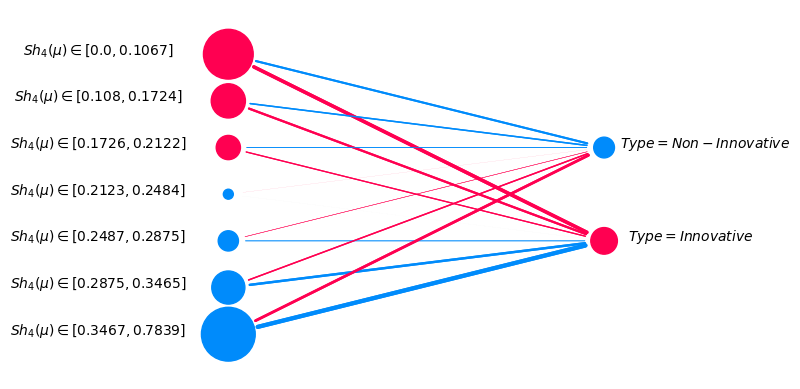

In [20]:
from cgt_perezsechi.visualization.graph import draw

positive_alpha = 0
negative_alpha = 0
positive_beta = 0
negative_beta = 0
draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    positive_color=positive_color,
    negative_color=negative_color,
    layout="shell",
    node_label_size_limit=5000,
    node_pos={
        r'$Type = Non-Innovative$': (350, 500),
        r'$Type = Innovative$': (350, 300),
        r'$Sh_4(\mu) \in [0.0,0.1067]$': (90, 700),
        r'$Sh_4(\mu) \in [0.108,0.1724]$': (90, 600),
        r'$Sh_4(\mu) \in [0.1726,0.2122]$': (90, 500),
        r'$Sh_4(\mu) \in [0.2123,0.2484]$': (90, 400),
        r'$Sh_4(\mu) \in [0.2487,0.2875]$': (90, 300),
        r'$Sh_4(\mu) \in [0.2875,0.3465]$': (90, 200),
        r'$Sh_4(\mu) \in [0.3467,0.7839]$': (90, 100),
    },
    label_pos={
        r'$Type = Non-Innovative$': (420, 500),
        r'$Type = Innovative$': (410, 300),
        r'$Sh_4(\mu) \in [0.0,0.1067]$': (0, 700),
        r'$Sh_4(\mu) \in [0.108,0.1724]$': (0, 600),
        r'$Sh_4(\mu) \in [0.1726,0.2122]$': (0, 500),
        r'$Sh_4(\mu) \in [0.2123,0.2484]$': (0, 400),
        r'$Sh_4(\mu) \in [0.2487,0.2875]$': (0, 300),
        r'$Sh_4(\mu) \in [0.2875,0.3465]$': (0, 200),
        r'$Sh_4(\mu) \in [0.3467,0.7839]$': (0, 100),
    },
    plot_margin=0.1,
    label_color="#000000",
    output_path=os.path.join('..', '..', 'results', 'Cap7', 'Fig3.jpg')
)